Cargando 5 pistas. Esto puede tomar unos segundos...
Advertencia: No se encontró el archivo 'musica.wav'. Se omitirá del análisis.
Advertencia: No se encontró el archivo 'voz.wav'. Se omitirá del análisis.
Advertencia: No se encontró el archivo 'tops.wav'. Se omitirá del análisis.
Calculando la sonoridad perceptual (Escala Mel + Curva A)...
Mapeando choques frecuenciales globales...


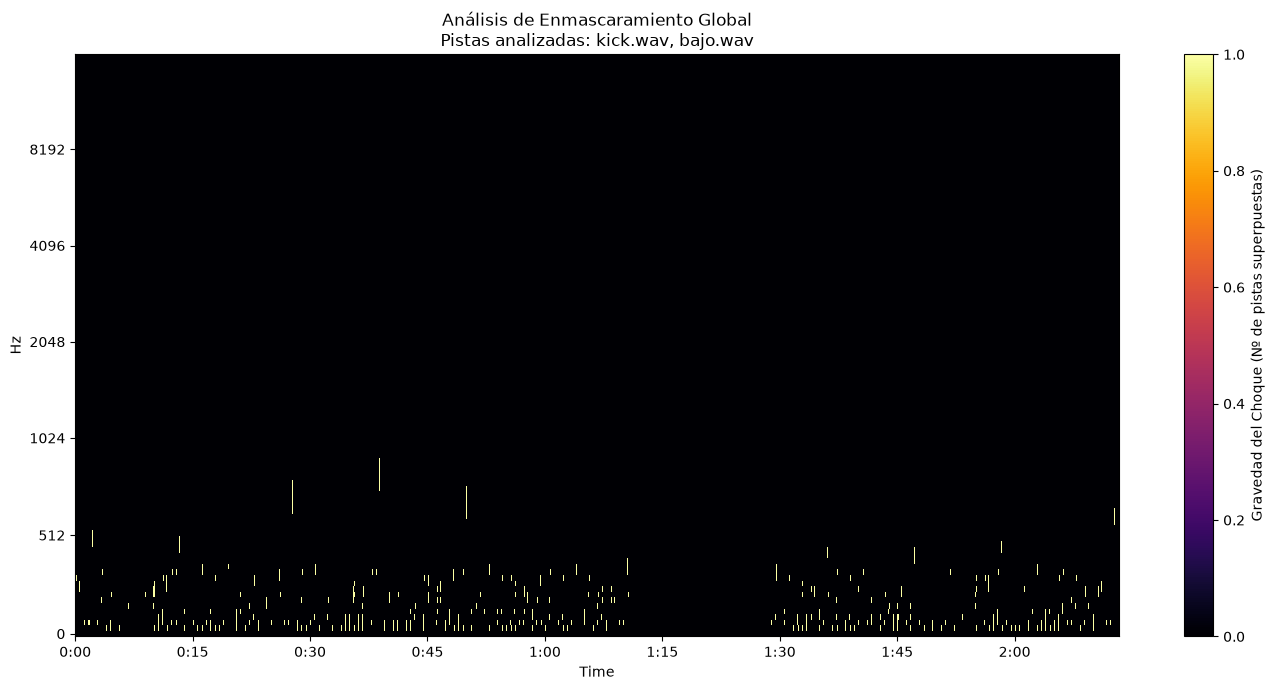

¡Análisis completado con éxito!


In [ ]:
import streamlit as st
import librosa
import numpy as np
import matplotlib.pyplot as plt

# --- CONFIGURACIÓN DE LA PÁGINA ---
st.set_page_config(page_title="MixViz - Pro-Q Edition", layout="wide")

st.title("🎛️ Analizador de Enmascaramiento y Sidechain")
st.markdown("Visualización de espectro estilo Pro-Q con sugerencias de ecualización dinámica.")

# --- BARRA LATERAL (CONTROLES) ---
st.sidebar.header("Parámetros de Análisis")

umbral_ruido = st.sidebar.slider(
    "Umbral de Ruido (dB)", 
    min_value=-80.0, max_value=-20.0, value=-50.0, step=1.0,
    help="Ignora los sonidos por debajo de este volumen."
)

margen_choque = st.sidebar.slider(
    "Margen de Choque (dB)", 
    min_value=0.5, max_value=12.0, value=3.0, step=0.5,
    help="Diferencia máxima en dB para considerar que las pistas chocan."
)

# --- ZONA DE CARGA DE ARCHIVOS ---
archivos_subidos = st.file_uploader(
    "Sube tus stems (Formato WAV)", 
    type=['wav'], 
    accept_multiple_files=True
)

# --- MOTOR DE ANÁLISIS ---
if st.button("Analizar Mezcla") and archivos_subidos:
    if len(archivos_subidos) < 2:
        st.error("Por favor, sube al menos 2 archivos para poder comparar.")
    else:
        with st.spinner('Procesando audio y generando visualización...'):
            pistas = []
            nombres = []
            sr_global = 44100
            
            # 1. Cargar los archivos desde la memoria web
            for archivo in archivos_subidos:
                y, sr = librosa.load(archivo, sr=sr_global, mono=True)
                pistas.append(y)
                nombres.append(archivo.name)
                
            # 2. Alinear longitudes
            min_len = min([len(y) for y in pistas])
            pistas = [y[:min_len] for y in pistas]
            
            # 3. Procesamiento Psicoacústico
            n_fft = 2048
            hop_length = 512
            n_mels = 128
            # Empezamos en 20Hz para que la escala logarítmica funcione bien
            mel_freqs = librosa.mel_frequencies(n_mels=n_mels, fmin=20.0, fmax=sr_global/2) 
            
            espectros_medios = []
            for y in pistas:
                S = librosa.feature.melspectrogram(y=y, sr=sr_global, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels, fmin=20.0)
                db_perc = librosa.perceptual_weighting(S, mel_freqs)
                # Promediamos la energía en el tiempo para obtener la curva de EQ
                espectro_medio = np.mean(db_perc, axis=1)
                espectros_medios.append(espectro_medio)
                
            # 4. Configurar Gráfico estilo FabFilter Pro-Q
            plt.style.use('dark_background')
            fig, ax = plt.subplots(figsize=(12, 6))
            colores = ['#00e6e6', '#ff3399', '#ffff00', '#33cc33', '#cc33ff']
            
            # Graficar el espectro de cada pista
            for i, (espectro, nombre) in enumerate(zip(espectros_medios, nombres)):
                ax.plot(mel_freqs, espectro, label=nombre, color=colores[i % len(colores)], linewidth=2.5, alpha=0.8)
                # Rellenar ligeramente bajo la curva para darle un toque más moderno
                ax.fill_between(mel_freqs, umbral_ruido, espectro, color=colores[i % len(colores)], alpha=0.1)

            # 5. Lógica Inteligente de Sidechain
            # Buscar automáticamente cuál es el kick y cuál es el bajo en los nombres de archivo
            idx_kick = next((i for i, n in enumerate(nombres) if 'kick' in n.lower()), None)
            idx_bajo = next((i for i, n in enumerate(nombres) if 'bajo' in n.lower() or 'bass' in n.lower()), None)
            
            # Si encuentra ambos, calcula la sugerencia de Sidechain
            if idx_kick is not None and idx_bajo is not None:
                kick_db = espectros_medios[idx_kick]
                bajo_db = espectros_medios[idx_bajo]
                
                # Zonas donde ambas superan el ruido y están cerca en volumen (choque)
                conflicto = (kick_db > umbral_ruido) & (bajo_db > umbral_ruido) & (np.abs(kick_db - bajo_db) < margen_choque)
                
                # Curva de sugerencia: cuánto deberías bajar el bajo
                atenuacion_sugerida = np.zeros_like(mel_freqs)
                atenuacion_sugerida[conflicto] = -np.abs(kick_db[conflicto] - bajo_db[conflicto]) - 2.0 
                
                # Dibujar la campana de atenuación en la base del gráfico
                ax.fill_between(mel_freqs, umbral_ruido, umbral_ruido + atenuacion_sugerida, 
                                color='white', alpha=0.35, label=f'Sugerencia Sidechain ({nombres[idx_bajo]})')

            # 6. Formateo visual del eje X e Y
            ax.set_xscale('log')
            ax.set_xlim([20, 20000]) # Rango humano completo
            
            max_db = np.max(espectros_medios) + 5
            ax.set_ylim([umbral_ruido, max_db])
            
            # Personalización de etiquetas y rejillas
            ax.set_xlabel('Frecuencia (Hz)', fontsize=11)
            ax.set_ylabel('Amplitud Percibida (dB)', fontsize=11)
            ax.set_title(f'Mapa de Frecuencias Promedio: {", ".join(nombres)}', fontsize=13)
            
            # Líneas de la cuadrícula (grilla)
            ax.grid(True, which="major", ls="-", alpha=0.2)
            ax.grid(True, which="minor", ls=":", alpha=0.1)
            ax.legend(loc='upper right')
            
            plt.tight_layout()
            
            # Mostrar en la aplicación web
            st.pyplot(fig)
            st.success("¡Análisis completado! Observa la zona blanca para ver los recortes sugeridos.")